### Grid search heatmaps — fp32 + class-weighted CE

One panel per model present in `../grid.csv`, shared colour scale. Validation macro-F1 averaged over seeds; blue ring = selected config. Panels appear as models finish, so re-run this once the whole grid lands. Writes `grid_heatmap.png`.

In [1]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# match the thesis body font (Computer Modern)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["cmr10", "DejaVu Serif"],
        "font.monospace": ["cmtt10", "DejaVu Sans Mono"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
    }
)
from matplotlib.patches import Rectangle

PRETTY = {
    "roberta-large": "RoBERTa-large",
    "roberta-base": "RoBERTa-base",
    "bert-large-uncased": "BERT-large",
    "bert-base-uncased": "BERT-base",
    "flang-roberta": "FLANG-RoBERTa",
    "flang-bert": "FLANG-BERT",
}
ORDER = [
    "roberta-large",
    "roberta-base",
    "bert-large-uncased",
    "flang-roberta",
    "flang-bert",
    "bert-base-uncased",
]

d = pl.read_csv(RESULTS_DIR / "grid.csv")
present = set(d["model"].unique().to_list())
models = [m for m in ORDER if m in present]
lrs = sorted(d["lr"].unique().to_list(), reverse=True)
batches = sorted(d["batch_size"].unique().to_list(), reverse=True)
print(models, lrs, batches)

['roberta-large', 'roberta-base', 'bert-large-uncased', 'flang-roberta', 'flang-bert', 'bert-base-uncased'] [2e-05, 1e-05, 5e-06] [32, 16, 8]


In [2]:
# one mean-macro-F1 matrix per model; shared colour scale across panels
mats, stds, wins, nseed = {}, {}, {}, {}
for m in models:
    sub = d.filter(pl.col("model") == m)
    nseed[m] = sub.select("seed").n_unique()
    agg = sub.group_by(["batch_size", "lr"]).agg(
        pl.col("val_macro_f1").mean().alias("v"),
        pl.col("val_macro_f1").std(ddof=0).alias("s"),
    )
    cell = {(r["batch_size"], r["lr"]): r["v"] for r in agg.iter_rows(named=True)}
    cellstd = {(r["batch_size"], r["lr"]): r["s"] for r in agg.iter_rows(named=True)}
    M = np.full((len(batches), len(lrs)), np.nan)
    for i, b in enumerate(batches):
        for j, lr in enumerate(lrs):
            if (b, lr) in cell:
                M[i, j] = cell[(b, lr)]
    S = np.full((len(batches), len(lrs)), np.nan)
    for i, b in enumerate(batches):
        for j, lr in enumerate(lrs):
            if (b, lr) in cellstd:
                S[i, j] = cellstd[(b, lr)]
    mats[m], stds[m] = M, S
    wins[m] = np.unravel_index(np.nanargmax(M), M.shape)
    print(
        m,
        nseed[m],
        "seeds, best",
        f"{np.nanmax(M):.4f}",
        "at lr",
        lrs[wins[m][1]],
        "b",
        batches[wins[m][0]],
    )

vmin = min(np.nanmin(M) for M in mats.values())
vmax = max(np.nanmax(M) for M in mats.values())

roberta-large 3 seeds, best 0.7358 at lr 1e-05 b 16
roberta-base 3 seeds, best 0.6899 at lr 1e-05 b 32
bert-large-uncased 3 seeds, best 0.6753 at lr 1e-05 b 8
flang-roberta 3 seeds, best 0.6753 at lr 2e-05 b 8
flang-bert 3 seeds, best 0.6588 at lr 2e-05 b 16
bert-base-uncased 3 seeds, best 0.6383 at lr 2e-05 b 8


C:\Users\vpati\AppData\Local\Temp\ipykernel_40384\538256494.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axes = plt.subplots(nrows, ncols, figsize=(6.1, 4.6), squeeze=False)


saved grid_heatmap.png / .pdf


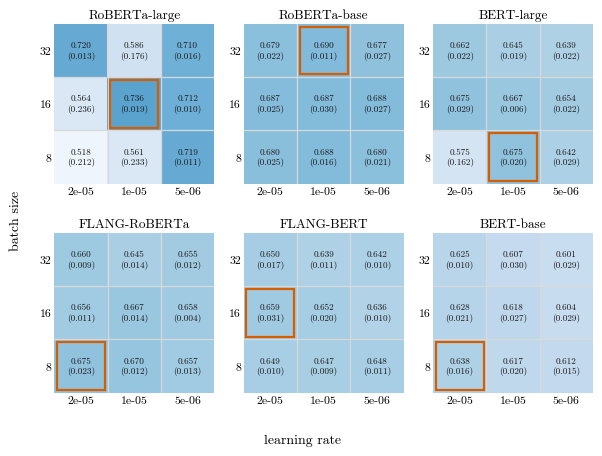

In [3]:
ncols = min(3, len(models))
nrows = -(-len(models) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6.1, 4.6), squeeze=False)

# Blues capped at mid-strength so black text stays readable in every cell
light_blues = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "light_blues", plt.get_cmap("Blues")(np.linspace(0.04, 0.55, 256))
)

for ax, m in zip(axes.flat, models):
    M = mats[m]
    ax.imshow(M, cmap=light_blues, aspect="equal", vmin=vmin, vmax=vmax)
    for x in range(1, len(lrs)):
        ax.axvline(x - 0.5, color="#d9d9d9", lw=0.9)
    for y in range(1, len(batches)):
        ax.axhline(y - 0.5, color="#d9d9d9", lw=0.9)
    for i in range(len(batches)):
        for j in range(len(lrs)):
            v = M[i, j]
            if np.isnan(v):
                ax.text(j, i, "-", ha="center", va="center", color="#bbb", fontsize=9)
                continue
            sd = stds[m][i, j]
            label = f"{v:.3f}" if np.isnan(sd) else f"{v:.3f}" + chr(10) + f"({sd:.3f})"
            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                color="#1a1a1a",
                fontsize=6.6,
                linespacing=1.25,
            )
    bi, bj = wins[m]
    ax.add_patch(
        Rectangle(
            (bj - 0.45, bi - 0.45),
            0.9,
            0.9,
            fill=False,
            edgecolor="#D55E00",
            lw=1.6,
            zorder=5,
        )
    )
    ax.set_xticks(range(len(lrs)), [f"{lr:.0e}" for lr in lrs], fontsize=8.5)
    ax.set_yticks(range(len(batches)), batches, fontsize=8.5)
    ax.tick_params(length=0, pad=2)
    for s in ax.spines.values():
        s.set_visible(False)
    title = PRETTY[m] + ("" if nseed[m] == 3 else f"  ({nseed[m]}/3 seeds)")
    ax.set_title(title, fontsize=9.5, pad=4)

for ax in axes.flat[len(models) :]:
    ax.set_visible(False)

fig.supxlabel("learning rate", fontsize=10)
fig.supylabel("batch size", fontsize=10)
fig.tight_layout()
fig.savefig("grid_heatmap.png", dpi=300, bbox_inches="tight", facecolor="white")
fig.savefig("grid_heatmap.pdf", bbox_inches="tight", facecolor="white")
print("saved grid_heatmap.png / .pdf")